In [5]:
import pandas as pd

flights = pd.read_csv("data/nyc_flights.csv")
weather = pd.read_csv("data/nyc_weather.csv")

print(flights.shape)
print(weather.shape)
flights.head()

(336776, 19)
(26115, 15)


,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01T10:00:00Z
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01T11:00:00Z


In [6]:
flights = flights.dropna(subset=["dep_delay"])

print(flights.shape)
print("Delayed 15+ min:", (flights["dep_delay"] >= 15).mean())
print("Delayed any:", (flights["dep_delay"] > 0).mean())

(328521, 19)
Delayed 15+ min: 0.22194623783563303
Delayed any: 0.3909400007914258


In [7]:
flights["delayed"] = (flights["dep_delay"] > 0).astype(int)

drop_cols = ["dep_time", "arr_time", "arr_delay", "air_time", "dep_delay"]
flights = flights.drop(columns=drop_cols)

print(flights["delayed"].value_counts(normalize=True))
print(flights.columns.tolist())

delayed
0    0.60906
1    0.39094
Name: proportion, dtype: float64
['year', 'month', 'day', 'sched_dep_time', 'sched_arr_time', 'carrier', 'flight', 'tailnum', 'origin', 'dest', 'distance', 'hour', 'minute', 'time_hour', 'delayed']


In [8]:
print(weather.shape)
print(weather.columns.tolist())
print(weather.isna().sum())
weather.head()

(26115, 15)
['origin', 'year', 'month', 'day', 'hour', 'temp', 'dewp', 'humid', 'wind_dir', 'wind_speed', 'wind_gust', 'precip', 'pressure', 'visib', 'time_hour']
origin            0
year              0
month             0
day               0
hour              0
temp              1
dewp              1
humid             1
wind_dir        460
wind_speed        4
wind_gust     20778
precip            0
pressure       2729
visib             0
time_hour         0
dtype: int64


,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,EWR,2013,1,1,1,39.02,26.06,59.37,270.0,10.35702,NaN,0.0,1012.0,10.0,2013-01-01T06:00:00Z
1,EWR,2013,1,1,2,39.02,26.96,61.63,250.0,8.05546,NaN,0.0,1012.3,10.0,2013-01-01T07:00:00Z
2,EWR,2013,1,1,3,39.02,28.04,64.43,240.0,11.50780,NaN,0.0,1012.5,10.0,2013-01-01T08:00:00Z
3,EWR,2013,1,1,4,39.92,28.04,62.21,250.0,12.65858,NaN,0.0,1012.2,10.0,2013-01-01T09:00:00Z
4,EWR,2013,1,1,5,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0,2013-01-01T10:00:00Z


In [9]:
weather_small = weather.drop(columns=["wind_gust", "year", "month", "day", "hour"])
weather_small = weather_small.drop_duplicates(subset=["origin", "time_hour"])

merged = flights.merge(weather_small, on=["origin", "time_hour"], how="left")

print(flights.shape, merged.shape)
print(merged.isna().sum())

(328521, 15) (328521, 23)
year                  0
month                 0
day                   0
sched_dep_time        0
sched_arr_time        0
carrier               0
flight                0
tailnum               0
origin                0
dest                  0
distance              0
hour                  0
minute                0
time_hour             0
delayed               0
temp               1545
dewp               1545
humid              1545
wind_dir           9601
wind_speed         1606
precip             1528
pressure          36319
visib              1528
dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

X = merged.drop(columns=["delayed", "time_hour", "year"])
y = merged["delayed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(262816, 20) (65705, 20)
0.3909389078290515 0.3909443725743855


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score

cat_cols = ["carrier", "origin", "dest"]
num_cols = ["month", "day", "sched_dep_time", "sched_arr_time", "distance",
            "hour", "minute", "temp", "dewp", "humid", "wind_dir",
            "wind_speed", "precip", "pressure", "visib"]

num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000)),
])

model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("Recall (delayed):", recall_score(y_test, pred))

Accuracy: 0.6652461760900997
ROC-AUC: 0.6941542070851859
Recall (delayed): 0.40857242963366686


In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_proba))

Accuracy: 0.6652461760900997
Precision: 0.6067175395999538
Recall: 0.40857242963366686
F1 Score: 0.4883098755379784
ROC-AUC: 0.6941542070851859


In [12]:
from sklearn.ensemble import HistGradientBoostingClassifier

lr_model = model

cols = cat_cols + num_cols
Xtr = X_train[cols].copy()
Xte = X_test[cols].copy()
for c in cat_cols:
    Xtr[c] = Xtr[c].astype("category")
    Xte[c] = Xte[c].astype("category")

gb = HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=42)
gb.fit(Xtr, y_train)

pred = gb.predict(Xte)
proba = gb.predict_proba(Xte)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("Recall (delayed):", recall_score(y_test, pred))

Accuracy: 0.7043908378357812
ROC-AUC: 0.7459333430177932
Recall (delayed): 0.47662241600809746


In [13]:
from sklearn.metrics import precision_score, f1_score

print("HistGradientBoosting Results")
print("----------------------------")
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("ROC-AUC  :", roc_auc_score(y_test, proba))

HistGradientBoosting Results
----------------------------
Accuracy : 0.7043908378357812
Precision: 0.6718801448798156
Recall   : 0.47662241600809746
F1 Score : 0.5576533284748002
ROC-AUC  : 0.7459333430177932


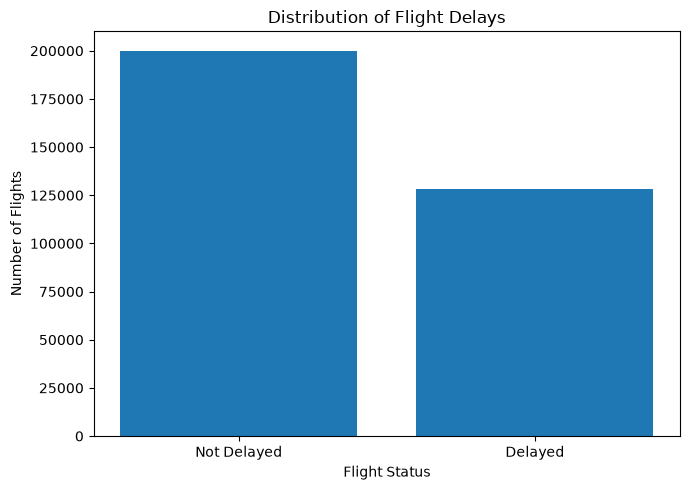

In [14]:
import matplotlib.pyplot as plt

delay_counts = y.value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Not Delayed", "Delayed"],
    delay_counts.values
)

plt.xlabel("Flight Status")
plt.ylabel("Number of Flights")
plt.title("Distribution of Flight Delays")

plt.tight_layout()
plt.savefig("plots/v2_delay_distribution.png", dpi=300)
plt.show()

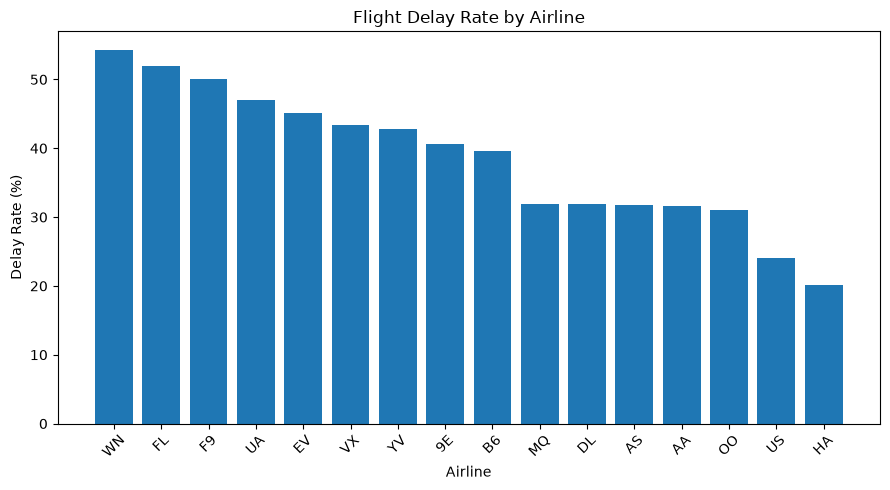

In [15]:
airline_delay_rate = (
    pd.concat([X_train.assign(delayed=y_train), X_test.assign(delayed=y_test)])
    .groupby("carrier")["delayed"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    airline_delay_rate.index,
    airline_delay_rate.values * 100
)

plt.xlabel("Airline")
plt.ylabel("Delay Rate (%)")
plt.title("Flight Delay Rate by Airline")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("plots/v2_delay_rate_by_airline.png", dpi=300)
plt.show()

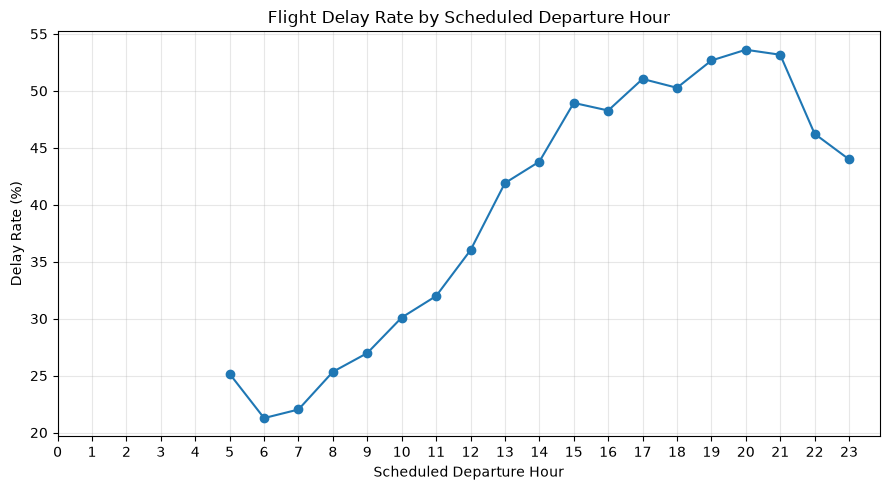

In [16]:
hour_delay_rate = (
    pd.concat([X_train.assign(delayed=y_train), X_test.assign(delayed=y_test)])
    .groupby("hour")["delayed"]
    .mean()
)

plt.figure(figsize=(9, 5))

plt.plot(
    hour_delay_rate.index,
    hour_delay_rate.values * 100,
    marker="o"
)

plt.xlabel("Scheduled Departure Hour")
plt.ylabel("Delay Rate (%)")
plt.title("Flight Delay Rate by Scheduled Departure Hour")

plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plots/v2_delay_rate_by_hour.png", dpi=300)
plt.show()

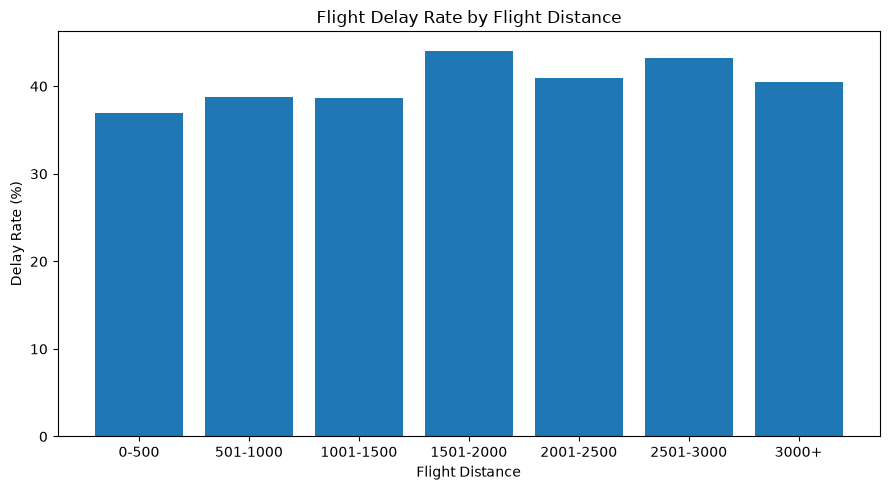

In [17]:
distance_delay_rate = (
    pd.concat([X_train.assign(delayed=y_train), X_test.assign(delayed=y_test)])
    .assign(
        distance_bin=lambda x: pd.cut(
            x["distance"],
            bins=[0, 500, 1000, 1500, 2000, 2500, 3000, float("inf")],
            labels=[
                "0-500",
                "501-1000",
                "1001-1500",
                "1501-2000",
                "2001-2500",
                "2501-3000",
                "3000+"
            ]
        )
    )
    .groupby("distance_bin", observed=True)["delayed"]
    .mean()
)

plt.figure(figsize=(9, 5))

plt.bar(
    distance_delay_rate.index.astype(str),
    distance_delay_rate.values * 100
)

plt.xlabel("Flight Distance")
plt.ylabel("Delay Rate (%)")
plt.title("Flight Delay Rate by Flight Distance")

plt.tight_layout()
plt.savefig("plots/v2_delay_rate_by_distance.png", dpi=300)
plt.show()

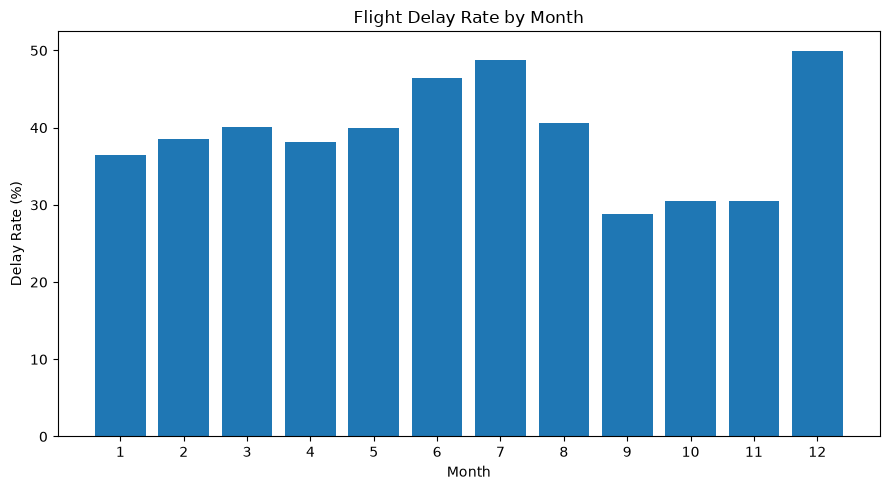

In [18]:
month_delay_rate = (
    pd.concat([X_train.assign(delayed=y_train), X_test.assign(delayed=y_test)])
    .groupby("month")["delayed"]
    .mean()
)

plt.figure(figsize=(9, 5))

plt.bar(
    month_delay_rate.index,
    month_delay_rate.values * 100
)

plt.xlabel("Month")
plt.ylabel("Delay Rate (%)")
plt.title("Flight Delay Rate by Month")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.savefig("plots/v2_delay_rate_by_month.png", dpi=300)
plt.show()

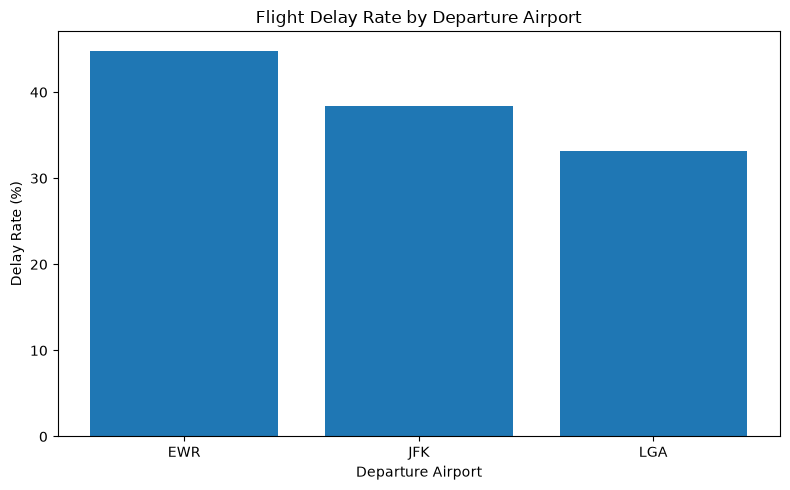

In [19]:
airport_delay_rate = (
    pd.concat([X_train.assign(delayed=y_train), X_test.assign(delayed=y_test)])
    .groupby("origin")["delayed"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    airport_delay_rate.index,
    airport_delay_rate.values * 100
)

plt.xlabel("Departure Airport")
plt.ylabel("Delay Rate (%)")
plt.title("Flight Delay Rate by Departure Airport")

plt.tight_layout()
plt.savefig("plots/v2_delay_rate_by_origin.png", dpi=300)
plt.show()

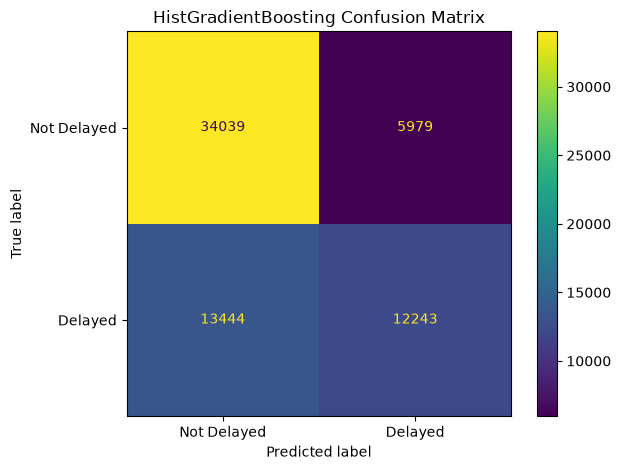

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Delayed", "Delayed"]
)

disp.plot()

plt.title("HistGradientBoosting Confusion Matrix")
plt.tight_layout()

plt.savefig("plots/v2_hgb_confusion_matrix.png", dpi=300)
plt.show()

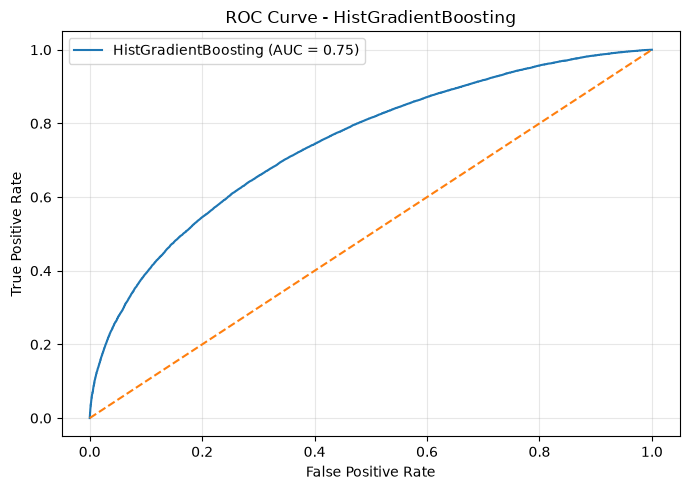

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, proba)
auc_score = roc_auc_score(y_test, proba)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"HistGradientBoosting (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - HistGradientBoosting")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plots/v2_hgb_roc_curve.png", dpi=300)
plt.show()

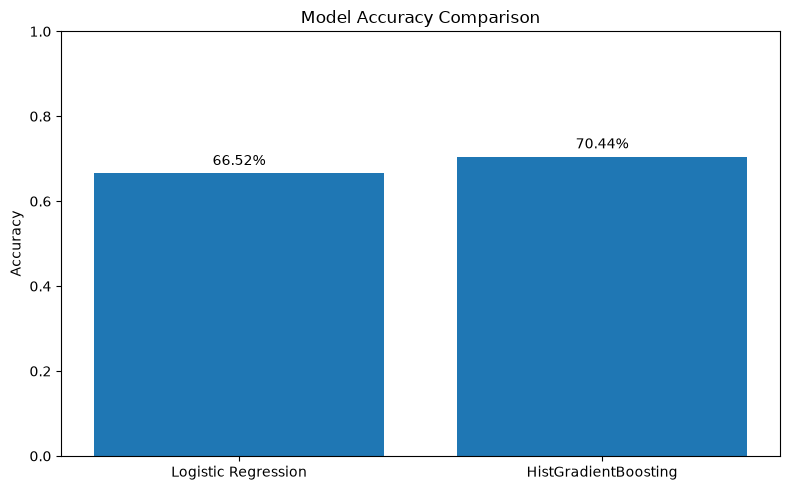

In [22]:
models = ["Logistic Regression", "HistGradientBoosting"]
accuracy_scores = [0.6652, 0.7044]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracy_scores)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 1)

for i, score in enumerate(accuracy_scores):
    plt.text(i, score + 0.02, f"{score * 100:.2f}%", ha="center")

plt.tight_layout()
plt.savefig("plots/v2_model_accuracy_comparison.png", dpi=300)
plt.show()

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=150,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_proba))

Random Forest Results
---------------------
Accuracy : 0.7082566014762955
Precision: 0.6923394711992445
Recall   : 0.4566901545528867
F1 Score : 0.550350683774718
ROC-AUC  : 0.7514330166249807


In [75]:
print("RF expects:", rf_model.named_steps["clf"].n_features_in_)
print("Preprocessor outputs:", len(
    rf_model.named_steps["prep"].get_feature_names_out()
))

RF expects: 138
Preprocessor outputs: 138


In [24]:
from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline([
    ("prep", preprocess),
    ("clf", DecisionTreeClassifier(
        max_depth=20,
        random_state=42
    ))
])

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree Results")
print("--------------------")
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))
print("ROC-AUC  :", roc_auc_score(y_test, dt_proba))

Decision Tree Results
--------------------
Accuracy : 0.6703142835400654
Precision: 0.5956465947435958
Recall   : 0.48791217347296295
F1 Score : 0.5364235576099983
ROC-AUC  : 0.6551498248103143


In [77]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("prep", preprocess),
    ("clf", KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
        n_jobs=-1
    ))
])

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_proba = knn_model.predict_proba(X_test)[:, 1]

print("KNN Results")
print("-----------")
print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall   :", recall_score(y_test, knn_pred))
print("F1 Score :", f1_score(y_test, knn_pred))
print("ROC-AUC  :", roc_auc_score(y_test, knn_proba))

KNN Results
-----------
Accuracy : 0.6897952971615554
Precision: 0.6325918520369908
Recall   : 0.4926616576478374
F1 Score : 0.5539262890659197
ROC-AUC  : 0.7260839213236592


In [26]:
rf_proba = rf_model.predict_proba(X_test)[:, 1]

In [27]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.20, 0.61, 0.01)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:
    rf_threshold_pred = (rf_proba >= threshold).astype(int)
    f1 = f1_score(y_test, rf_threshold_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best Threshold: 0.3200000000000001
Best F1 Score: 0.6325368690821478


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_threshold_pred = (rf_proba >= 0.32).astype(int)

print("Accuracy:", accuracy_score(y_test, rf_threshold_pred))
print("Precision:", precision_score(y_test, rf_threshold_pred))
print("Recall:", recall_score(y_test, rf_threshold_pred))
print("F1 Score:", f1_score(y_test, rf_threshold_pred))

Accuracy: 0.635568069401111
Precision: 0.5220640389097173
Recall: 0.8023124537703897
F1 Score: 0.6325368690821478


In [29]:
fine_thresholds = np.arange(0.25, 0.401, 0.001)

best_threshold = 0
best_f1 = 0

for threshold in fine_thresholds:
    threshold_pred = (rf_proba >= threshold).astype(int)
    f1 = f1_score(y_test, threshold_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best Threshold: 0.32300000000000006
Best F1 Score: 0.6327158109423525


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_threshold_pred = (rf_proba >= 0.323).astype(int)

print("Accuracy:", accuracy_score(y_test, rf_threshold_pred))
print("Precision:", precision_score(y_test, rf_threshold_pred))
print("Recall:", recall_score(y_test, rf_threshold_pred))
print("F1 Score:", f1_score(y_test, rf_threshold_pred))

Accuracy: 0.6382162696902823
Precision: 0.5245427063585592
Recall: 0.7970958072176587
F1 Score: 0.6327158109423525


In [33]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_tuned = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=250,
    max_leaf_nodes=31,
    min_samples_leaf=30,
    l2_regularization=1.0,
    random_state=42
)

hgb_tuned.fit(Xtr, y_train)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.08
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",250
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",30
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",1.0
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing va

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

hgb_tuned_pred = hgb_tuned.predict(Xte)
hgb_tuned_proba = hgb_tuned.predict_proba(Xte)[:, 1]

print("Accuracy:", accuracy_score(y_test, hgb_tuned_pred))
print("Precision:", precision_score(y_test, hgb_tuned_pred))
print("Recall:", recall_score(y_test, hgb_tuned_pred))
print("F1 Score:", f1_score(y_test, hgb_tuned_pred))
print("ROC-AUC:", roc_auc_score(y_test, hgb_tuned_proba))

Accuracy: 0.7069172817898182
Precision: 0.6752425596860351
Recall: 0.4822672947405302
F1 Score: 0.5626689074103514
ROC-AUC: 0.7506667207449255


In [39]:
import pandas as pd

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "HistGradientBoosting"
    ],
    "Accuracy": [
        0.665246,
        0.670314,
        0.708257,
        0.689795,
        0.706917
    ],
    "Precision": [
        0.606718,
        0.595647,
        0.692339,
        0.632592,
        0.675243
    ],
    "Recall": [
        0.408572,
        0.487912,
        0.456690,
        0.492662,
        0.482267
    ],
    "F1 Score": [
        0.488310,
        0.536424,
        0.550351,
        0.553926,
        0.562669
    ],
    "ROC-AUC": [
        0.694154,
        0.655150,
        0.751433,
        0.726084,
        0.750667
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.665246,0.606718,0.408572,0.488310,0.694154
1,Decision Tree,0.670314,0.595647,0.487912,0.536424,0.655150
2,Random Forest,0.708257,0.692339,0.456690,0.550351,0.751433
3,KNN,0.689795,0.632592,0.492662,0.553926,0.726084
4,HistGradientBoosting,0.706917,0.675243,0.482267,0.562669,0.750667


In [40]:
knn_proba = knn_model.predict_proba(X_test)[:, 1]

In [41]:
ensemble_proba = (
    rf_proba +
    hgb_tuned_proba +
    knn_proba
) / 3

print(ensemble_proba[:10])

[0.61214134 0.39179718 0.66890721 0.21005426 0.42602205 0.64701785
 0.3044206  0.3193925  0.44440247 0.28254112]


In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

ensemble_pred = (ensemble_proba >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, ensemble_pred))
print("Precision:", precision_score(y_test, ensemble_pred))
print("Recall:", recall_score(y_test, ensemble_pred))
print("F1 Score:", f1_score(y_test, ensemble_pred))
print("ROC-AUC:", roc_auc_score(y_test, ensemble_proba))

Accuracy: 0.7113766075641124
Precision: 0.687322373920312
Recall: 0.48016506404017595
F1 Score: 0.5653648698203154
ROC-AUC: 0.7548900421524216


In [43]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

thresholds = np.arange(0.30, 0.61, 0.01)

results = []

for threshold in thresholds:
    pred = (ensemble_proba >= threshold).astype(int)

    accuracy = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append((threshold, accuracy, f1))

results_df = pd.DataFrame(
    results,
    columns=["Threshold", "Accuracy", "F1"]
)

results_df[results_df["Accuracy"] >= 0.70].sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,Accuracy,F1
13,0.43,0.702838,0.614230
14,0.44,0.704939,0.608889
15,0.45,0.707496,0.603429
16,0.46,0.708637,0.596968
17,0.47,0.709094,0.588716
18,0.48,0.709292,0.580207
19,0.49,0.710905,0.573616
20,0.50,0.711377,0.565365
21,0.51,0.711498,0.557413
22,0.52,0.710098,0.546455


In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

ensemble_pred_043 = (ensemble_proba >= 0.43).astype(int)

print("Accuracy:", accuracy_score(y_test, ensemble_pred_043))
print("Precision:", precision_score(y_test, ensemble_pred_043))
print("Recall:", recall_score(y_test, ensemble_pred_043))
print("F1 Score:", f1_score(y_test, ensemble_pred_043))

Accuracy: 0.7028384445628186
Precision: 0.6236058733852202
Recall: 0.6051310001167906
F1 Score: 0.6142295457688736


In [45]:
model_results_final = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "HistGradientBoosting",
        "Ensemble"
    ],
    "Accuracy": [
        0.665246,
        0.670314,
        0.708257,
        0.689795,
        0.706917,
        0.702838
    ],
    "Precision": [
        0.606718,
        0.595647,
        0.692339,
        0.632592,
        0.675243,
        0.623606
    ],
    "Recall": [
        0.408572,
        0.487912,
        0.456690,
        0.492662,
        0.482267,
        0.605131
    ],
    "F1 Score": [
        0.488310,
        0.536424,
        0.550351,
        0.553926,
        0.562669,
        0.614230
    ],
    "ROC-AUC": [
        0.694154,
        0.655150,
        0.751433,
        0.726084,
        0.750667,
        0.754890
    ]
})

model_results_final

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.665246,0.606718,0.408572,0.488310,0.694154
1,Decision Tree,0.670314,0.595647,0.487912,0.536424,0.655150
2,Random Forest,0.708257,0.692339,0.456690,0.550351,0.751433
3,KNN,0.689795,0.632592,0.492662,0.553926,0.726084
4,HistGradientBoosting,0.706917,0.675243,0.482267,0.562669,0.750667
5,Ensemble,0.702838,0.623606,0.605131,0.614230,0.754890


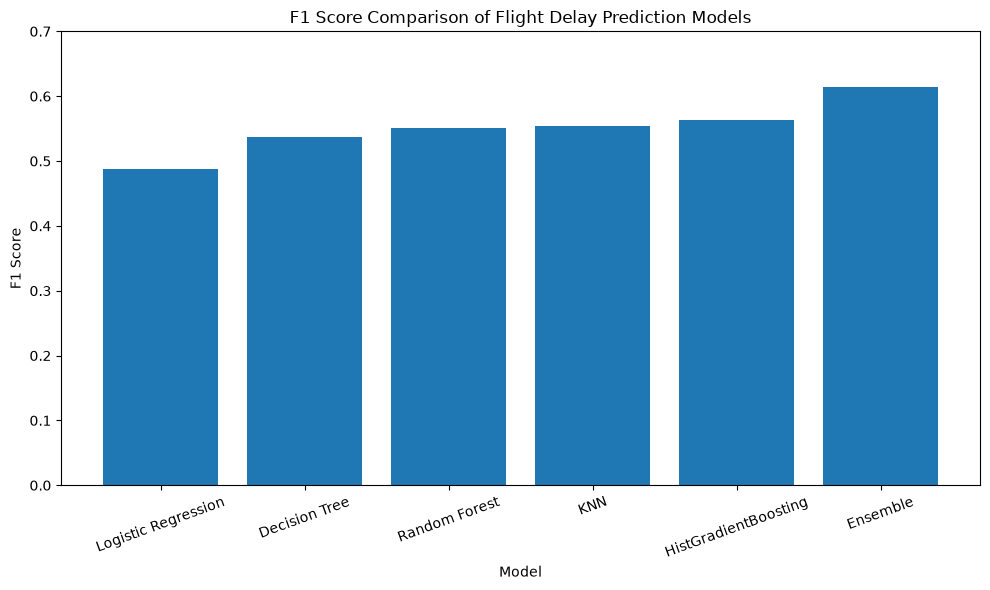

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    model_results_final["Model"],
    model_results_final["F1 Score"]
)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("F1 Score Comparison of Flight Delay Prediction Models")
plt.xticks(rotation=20)
plt.ylim(0, 0.7)

plt.tight_layout()
plt.savefig("plots/v2_model_f1_comparison.png", dpi=300)
plt.show()

In [48]:
import imblearn

print(imblearn.__version__)

0.14.2


In [50]:
X_train.dtypes

month               int64
day                 int64
sched_dep_time      int64
sched_arr_time      int64
carrier               str
flight              int64
tailnum               str
origin                str
dest                  str
distance            int64
hour                int64
minute              int64
temp              float64
dewp              float64
humid             float64
wind_dir          float64
wind_speed        float64
precip            float64
pressure          float64
visib             float64
dtype: object

In [52]:
X_train_smote.isna().sum().sort_values(ascending=False).head(10)

pressure      29045
wind_dir       7670
wind_speed     1286
humid          1231
dewp           1231
temp           1231
visib          1216
precip         1216
day               0
month             0
dtype: int64

In [54]:
X_train_smote = X_train.drop(columns=["flight", "tailnum"]).copy()

for col in num_cols:
    X_train_smote[col] = X_train_smote[col].fillna(
        X_train_smote[col].median()
    )

print("Remaining missing values:")
print(X_train_smote.isna().sum().sum())

Remaining missing values:
0


In [55]:
categorical_indices = [
    X_train_smote.columns.get_loc(col)
    for col in cat_cols
]

smotenc = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42
)

X_train_resampled, y_train_resampled = smotenc.fit_resample(
    X_train_smote,
    y_train_smote
)

print("Original training shape:", X_train_smote.shape)
print("Resampled training shape:", X_train_resampled.shape)

print("\nOriginal target distribution:")
print(y_train_smote.value_counts())

print("\nResampled target distribution:")
print(y_train_resampled.value_counts())

Original training shape: (262816, 18)
Resampled training shape: (320142, 18)

Original target distribution:
delayed
0    160071
1    102745
Name: count, dtype: int64

Resampled target distribution:
delayed
0    160071
1    160071
Name: count, dtype: int64


In [57]:
rf_smote = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=150,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ))
])

rf_smote.fit(X_train_resampled, y_train_resampled)

rf_smote_pred = rf_smote.predict(X_test)
rf_smote_proba = rf_smote.predict_proba(X_test)[:, 1]

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, rf_smote_pred))
print("Precision:", precision_score(y_test, rf_smote_pred))
print("Recall:", recall_score(y_test, rf_smote_pred))
print("F1 Score:", f1_score(y_test, rf_smote_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_smote_proba))

Accuracy: 0.6947112091926033
Precision: 0.6075441412520064
Recall: 0.6188733600654027
F1 Score: 0.61315642296492
ROC-AUC: 0.7489055986627172


In [59]:
thresholds = np.arange(0.30, 0.61, 0.01)

results = []

for threshold in thresholds:
    pred = (rf_smote_proba >= threshold).astype(int)

    accuracy = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append((threshold, accuracy, f1))

smote_threshold_results = pd.DataFrame(
    results,
    columns=["Threshold", "Accuracy", "F1"]
)

smote_threshold_results[
    smote_threshold_results["Accuracy"] >= 0.70
].sort_values("F1", ascending=False).head(10)

,Threshold,Accuracy,F1
22,0.52,0.700403,0.602636
23,0.53,0.703843,0.598394
24,0.54,0.704360,0.590337
25,0.55,0.705578,0.582010
26,0.56,0.707222,0.574337
27,0.57,0.707861,0.564986
28,0.58,0.706993,0.552612
29,0.59,0.706141,0.540832
30,0.60,0.705197,0.528940


In [60]:
from sklearn.model_selection import train_test_split

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

In [62]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

rf_smote = ImbPipeline([
    ("prep", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=42
    )),
])

rf_smote.fit(X_fit, y_fit)
rf_val_proba = rf_smote.predict_proba(X_val)[:, 1]

In [63]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("Validation ROC-AUC:", roc_auc_score(y_val, rf_val_proba))

results = []
for threshold in np.arange(0.30, 0.61, 0.01):
    pred = (rf_val_proba >= threshold).astype(int)
    results.append((threshold, accuracy_score(y_val, pred), f1_score(y_val, pred)))

val_results = pd.DataFrame(results, columns=["Threshold", "Accuracy", "F1"])
print(val_results.sort_values("F1", ascending=False).head(5))

Validation ROC-AUC: 0.7560969351628881
    Threshold  Accuracy        F1
10       0.40  0.652728  0.635896
11       0.41  0.659748  0.635766
8        0.38  0.638327  0.635588
9        0.39  0.645232  0.635511
12       0.42  0.666692  0.635380


In [64]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

train_mask = merged["month"] <= 9

X_early = merged.loc[train_mask, cols]
y_early = merged.loc[train_mask, "delayed"]
X_late = merged.loc[~train_mask, cols]
y_late = merged.loc[~train_mask, "delayed"]

rf_t = clone(rf_smote)
rf_t.fit(X_early, y_early)
rf_proba = rf_t.predict_proba(X_late)[:, 1]

lr_t = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=1000))])
lr_t.fit(X_early, y_early)
lr_proba = lr_t.predict_proba(X_late)[:, 1]

print("Baseline (always not delayed):", 1 - y_late.mean())
print("RF+SMOTE ROC-AUC:", roc_auc_score(y_late, rf_proba))
print("LogReg ROC-AUC:", roc_auc_score(y_late, lr_proba))

Baseline (always not delayed): 0.6315007608879442
RF+SMOTE ROC-AUC: 0.6930348456092454
LogReg ROC-AUC: 0.6545210439355883


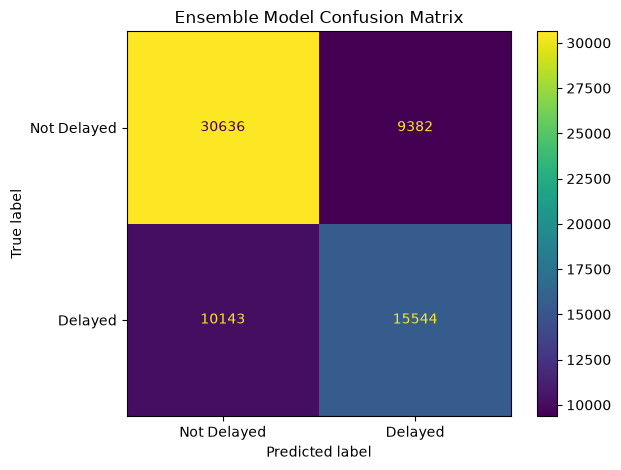

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ensemble_pred = (ensemble_proba >= 0.43).astype(int)

cm = confusion_matrix(y_test, ensemble_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Delayed", "Delayed"]
)

disp.plot(values_format="d")

plt.title("Ensemble Model Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "plots/v2_ensemble_confusion_matrix.png",
    dpi=300
)

plt.show()

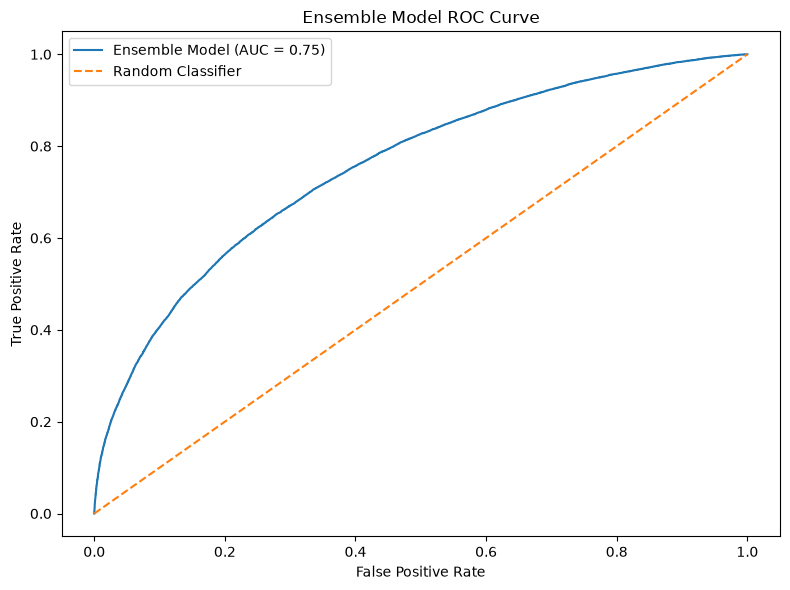

In [67]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, ensemble_proba)
auc_score = roc_auc_score(y_test, ensemble_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Ensemble Model (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Ensemble Model ROC Curve")
plt.legend()
plt.tight_layout()

plt.savefig(
    "plots/v2_ensemble_roc_curve.png",
    dpi=300
)

plt.show()

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "HistGradientBoosting",
        "Extra Trees",
        "Tuned Random Forest",
        "Random Forest + SMOTE",
        "Ensemble"
    ],
    "Accuracy": [
        0.665246,
        0.670314,
        0.708257,
        0.689795,
        0.706917,
        0.6935,
        0.699627,
        0.694711,
        0.702838
    ],
    "Precision": [
        0.606718,
        0.595647,
        0.692339,
        0.632592,
        0.675243,
        0.6723,
        0.684504,
        0.607544,
        0.623606
    ],
    "Recall": [
        0.408572,
        0.487912,
        0.456690,
        0.492662,
        0.482267,
        0.4214,
        0.429750,
        0.618873,
        0.605131
    ],
    "F1 Score": [
        0.488310,
        0.536424,
        0.550351,
        0.553926,
        0.562669,
        0.5181,
        0.528005,
        0.613156,
        0.614230
    ],
    "ROC-AUC": [
        0.694154,
        0.655150,
        0.751433,
        0.726084,
        0.750667,
        0.7349,
        0.738605,
        0.748906,
        0.754890
    ]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.665246,0.606718,0.408572,0.488310,0.694154
1,Decision Tree,0.670314,0.595647,0.487912,0.536424,0.655150
2,Random Forest,0.708257,0.692339,0.456690,0.550351,0.751433
3,KNN,0.689795,0.632592,0.492662,0.553926,0.726084
4,HistGradientBoosting,0.706917,0.675243,0.482267,0.562669,0.750667
5,Extra Trees,0.693500,0.672300,0.421400,0.518100,0.734900
6,Tuned Random Forest,0.699627,0.684504,0.429750,0.528005,0.738605
7,Random Forest + SMOTE,0.694711,0.607544,0.618873,0.613156,0.748906
8,Ensemble,0.702838,0.623606,0.605131,0.614230,0.754890


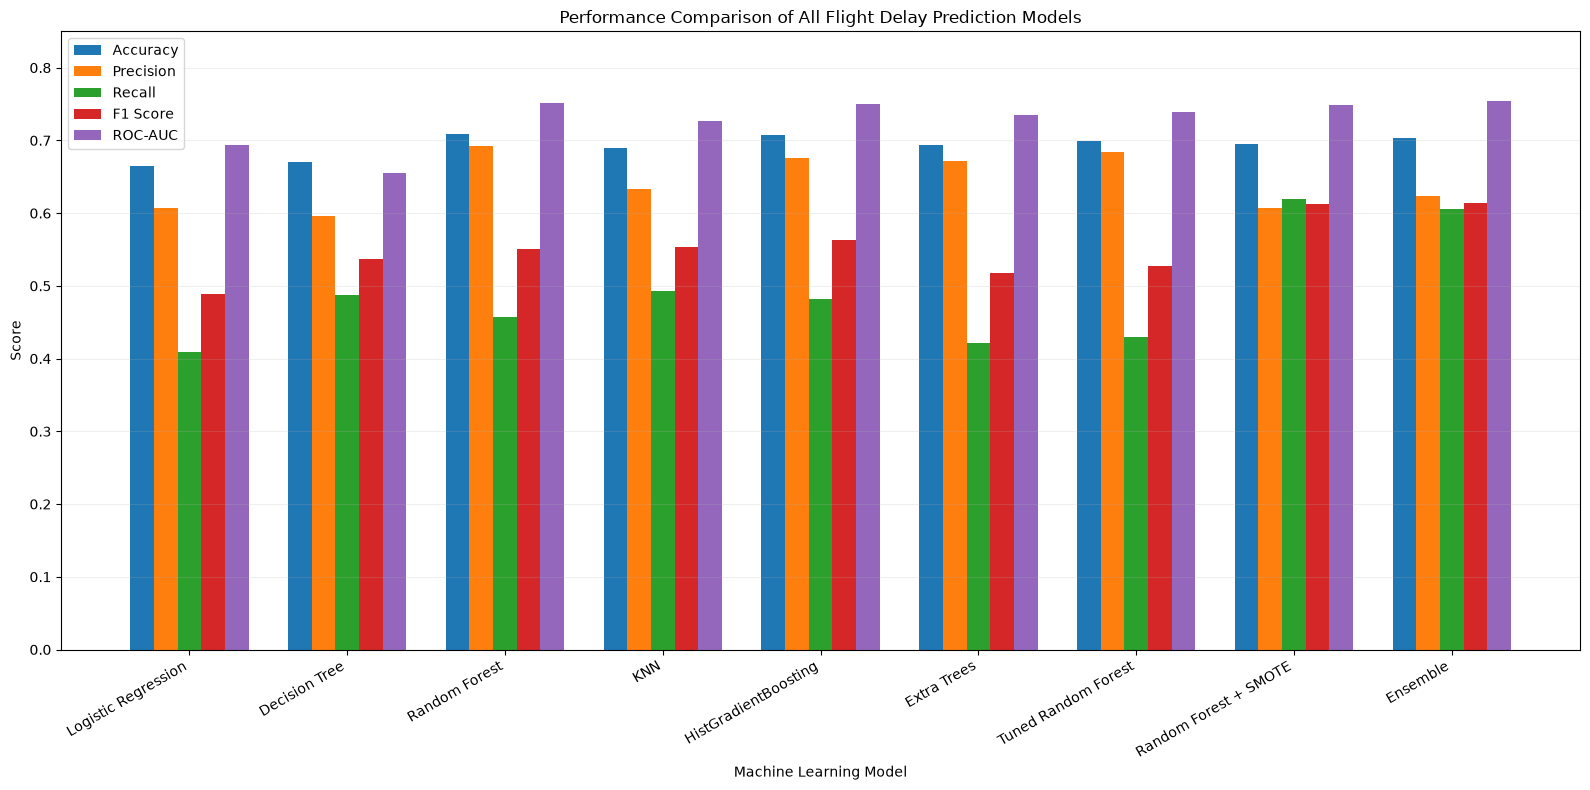

In [70]:
import numpy as np
import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

models = final_comparison["Model"]

x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(16, 8))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 2) * width,
        final_comparison[metric],
        width,
        label=metric
    )

plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.title("Performance Comparison of All Flight Delay Prediction Models")

plt.xticks(
    x,
    models,
    rotation=30,
    ha="right"
)

plt.ylim(0, 0.85)
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()

plt.savefig(
    "plots/v2_all_models_metric_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [71]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(rf_model, "models/random_forest.pkl")
joblib.dump(hgb_tuned, "models/hist_gradient_boosting.pkl")
joblib.dump(knn_model, "models/knn.pkl")
joblib.dump(0.43, "models/ensemble_threshold.pkl")

print("Final ensemble models saved successfully.")

Final ensemble models saved successfully.


In [72]:
import joblib

rf_loaded = joblib.load("models/random_forest.pkl")
hgb_loaded = joblib.load("models/hist_gradient_boosting.pkl")
knn_loaded = joblib.load("models/knn.pkl")
threshold = joblib.load("models/ensemble_threshold.pkl")

print(type(rf_loaded))
print(type(hgb_loaded))
print(type(knn_loaded))
print("Threshold:", threshold)

<class 'sklearn.pipeline.Pipeline'>
<class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>
<class 'sklearn.pipeline.Pipeline'>
Threshold: 0.43


In [76]:
import joblib

joblib.dump(
    rf_model,
    "models/random_forest.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [78]:
import joblib

joblib.dump(
    knn_model,
    "models/knn.pkl"
)

print("KNN model saved successfully.")

KNN model saved successfully.
